# Experiment 3: Model comparison

The prompt (v4) is frozen; only the model varies.

### Why agreement is not the deciding metric

Experiment 2 suggested that agreement with the CLC reference cannot separate prompts, because it appeared to be lower on `unambiguous` rows than on `thin` ones. The same caution applies to models. A higher agreement score may indicate that a model is guessing the coarse regional
class rather than reading the habitat text, so it is reported here but not used to rank. 

### What is used instead

| criterion | reasoning |
|---|---|
| **validity** | invalid CLC codes or lost rows make a model unusable regardless of its scores |
| **calibration** | the production resolver routes on confidence; if confidence carries no information, that routing has no basis |
| **consistency** | stable answers on identical input |
| **prompt-stability** | how many codes change on reps |
| **cost per 100k** | practical constraint |

### Terra ceiling check

Terra is not a shipping candidate. Instead it's run on a 30-row subset to answert the following question:

> On rows where the cheap model disagrees with CLC, does a much stronger model agree with CLC or does it return the same answer as the cheap model? 

The second outcome would point at the reference rather than the model. The subset is deliberately biased toward the cheap model's failures, so Terra's score on it is not an accuracy estimate.

In [ ]:
import sys
import os
import pandas as pd
sys.path.insert(0, os.path.abspath('../..'))

from testing.util.gee_mapping import get_clc_mapping

from testing.util.analysis import cells_of, load_reference, guard, calibration, flip_rate, cost_of
from testing.util.process import process_csv
from util.config import RESULT_PATH, WORKING_DATA100
from testing.util.plots import plot_model_comparison, plot_cost_vs_quality, plot_flip_rate, plot_calibration

INPUT = WORKING_DATA100
EXP_2 = f'{RESULT_PATH}/exp2'
EXP_3 = f'{RESULT_PATH}/exp3'

get_clc_mapping(INPUT, f'{EXP_3}/corine_output.csv')
REF = load_reference(f'{EXP_3}/corine_output.csv')

work = pd.read_csv(INPUT, dtype={'row_id': str})

# GPT-5.x are reasoning models and reject `temperature` unless reasoning is switched off.
# 'none' is available from 5.1 onwards; plain gpt-5 has no 'none' option, so gpt-5-nano runs
# with reasoning on and no temperature control — its sampling is not directly comparable to
# the others'. Worth verifying with a single call per model before a full run.
MODEL_PARAMS = {
    'gpt-4.1-nano':  {'temperature': 0},
    'gpt-5-nano':    {'reasoning_effort': 'minimal'},
    'gpt-5.4-nano':  {'temperature': 0, 'reasoning_effort': 'none'},
    'gpt-5.4-mini':  {'temperature': 0, 'reasoning_effort': 'none'},
    'gpt-5.6-terra': {'temperature': 0, 'reasoning_effort': 'none'},
}
MODELS = ['gpt-5.4-nano', 'gpt-4.1-nano', 'gpt-5-nano', 'gpt-5.4-mini']

### Building the Terra subset

| block | n | what it is for |
|---|---|---|
| `crux_unamb_disagree` | 12 | clear habitat text, cheap model disagreed with CLC — the rows that distinguish "model is limited" from "reference is limited" |
| `boundary_inconsistent` | 8 | boundary rows where the cheap model was least consistent across reps |
| `control_unamb_agree` | 4 | rows the cheap model got right — does the stronger model break them? |
| `cultivated` | 3 | garden specimens |
| `thin_hallucination_check` | 3 | does the stronger model become *more* confident on rows with no habitat text? |

In [ ]:
v4_nano = pd.read_csv(f'{EXP_2}/version_4.csv', dtype={'id': str, 'clc_code': str})
c4 = cells_of(v4_nano, REF)

unamb = c4[c4.difficulty == 'unambiguous_candidate']
blocks = {
    'crux_unamb_disagree':      unamb[unamb.agree_L1 == False].sort_values('mean_conf', ascending=False).head(12),
    'cultivated':               c4[c4.difficulty == 'edge_cultivated'],
    'boundary_inconsistent':    c4[c4.difficulty == 'boundary_candidate'].sort_values('consistency').head(8),
    'control_unamb_agree':      unamb[unamb.agree_L1].head(4),
    'thin_hallucination_check': c4[c4.difficulty == 'thin'].sort_values('mean_conf', ascending=False).head(3),
}
reason = {rid: name for name, blk in blocks.items() for rid in blk['id']}
terra_rows = work[work['row_id'].isin(reason)].copy()
terra_rows['subset_reason'] = terra_rows['row_id'].map(reason)
terra_rows.to_csv(f'{RESULT_PATH}/terra30.csv', index=False)
print(terra_rows['subset_reason'].value_counts())

subset_reason
crux_unamb_disagree         12
boundary_inconsistent        8
control_unamb_agree          4
cultivated                   3
thin_hallucination_check     3
Name: count, dtype: int64


In [ ]:
PLAN = [   # v0 and v4 on the cheap models — this is what makes the stability question answerable
    ('gpt-4.1-nano',  work,        [0, 4], 5),
    ('gpt-5-nano',    work,        [0, 4], 5),
    ('gpt-5.4-mini',  work,        [4],    5),
    ('gpt-5.6-terra', terra_rows,  [4],    3),   # ceiling check, not a candidate
]

async def run(model, df, version, reps):
    frames = []
    for rep in range(reps):
        r = await process_csv(df, model, version, model_params=MODEL_PARAMS.get(model, {}))
        r['row_id'], r['difficulty'] = df['row_id'].values, df['difficulty_tag'].values
        r['rep'], r['version'], r['model_tested'] = rep, version, model
        frames.append(r)
    return pd.concat(frames, ignore_index=True)

for model, df, versions, reps in PLAN:
    for v in versions:
        out = f'{RESULT_PATH}/exp3_{model}_v{v}.csv'
        res = await run(model, df, v, reps)
        res.to_csv(out, index=False)
        usd = cost_of(res['clc_prompt_tokens'].sum(), res['clc_completion_tokens'].sum(),
                      res['clc_cached_tokens'].sum(), model)
        print(f'{model} v{v}: {len(res)} rows, ${usd:.4f}')

### Validity

A model that emits codes outside the taxonomy, or loses rows to errors, is not a viable
candidate whatever else it scores.

In [ ]:
def load(model, v=4):
    p = (f'{EXP_2}/version_4.csv' if (model == 'gpt-5.4-nano' and v == 4)
         else f'{EXP_3}/exp3_{model}_v{v}.csv')
    return pd.read_csv(p, dtype={'id': str, 'clc_code': str})

for m in MODELS:
    raw = load(m)
    guard(raw, expect_model=m, label=m)
    bad = raw[raw['clc_unknown_code']]['clc_code'].dropna().unique()[:5]
    print(f"unknown_code={raw['clc_unknown_code'].mean():.4f} "
          f"parse_fail={raw['clc_parse_failure'].mean():.4f} "
          f"{'invalid codes seen: ' + str(list(bad)) if len(bad) else ''}")

unknown_code=0.0000 parse_fail=0.0000 
unknown_code=0.0000 parse_fail=0.0000 
  ⚠ gpt-5-nano: 2/510 calls failed (0 rows fully lost)
unknown_code=0.0020 parse_fail=0.0000 invalid codes seen: ['301']
unknown_code=0.0000 parse_fail=0.0000 


`gpt-5-nano` is eliminated.

### Calibration

A model whose confidence carries information should show agreement rising from the low bands
to the high ones. A flat or falling curve would mean confidence is not usable for routing —
though note that agreement itself is a weak yardstick here, so a flat curve is also what two
opposing effects cancelling out would look like. Sample sizes per band are small; they are
annotated on the plots for that reason.

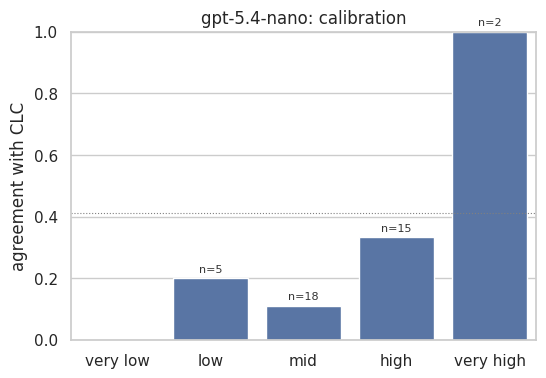

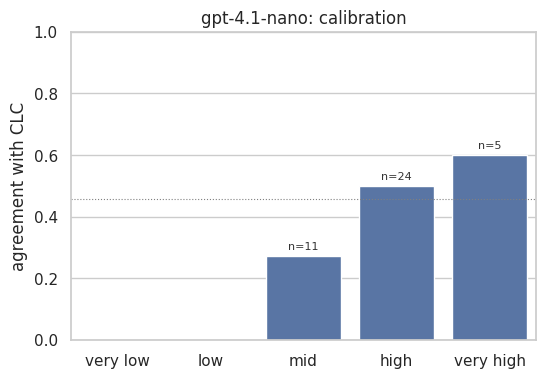

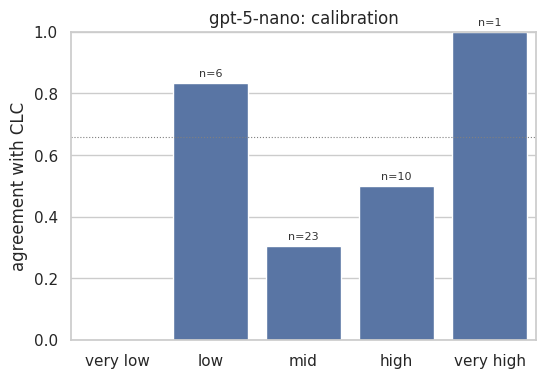

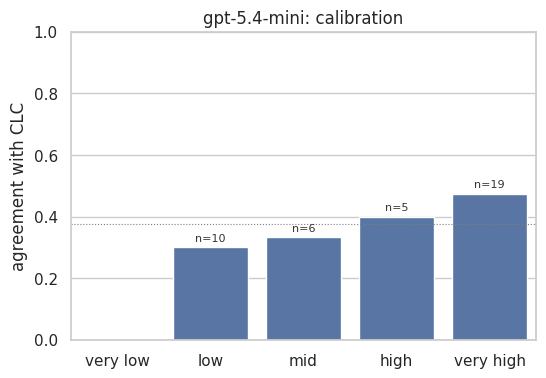

In [11]:
for m in MODELS:
    cal = calibration(cells_of(load(m), REF))
    # print(f'--- {m} ---')
    # print(cal)
    # print()
    if not cal.empty:
        plot_calibration(cal, title=f'{m}: calibration')

`gpt-5.4-mini` has the best calibration.

### Comparison

`agree_L1` and `agree_L3` are included for completeness. Per the note at the top, a higher
value here is not straightforwardly better.

In [12]:
rows = []
for m in MODELS:
    raw = load(m)
    cl = cells_of(raw, REF)
    rows.append({
        'model': m,
        'consistency': cl['consistency'].mean(),
        'mean_conf': cl['mean_conf'].mean(),
        'agree_L1': cl['agree_L1'].mean(),
        'agree_L3': cl['agree_L3'].mean(),
        'unknown_code': cl['unknown_code'].mean(),
        'rows_lost': int(cl['modal_code'].isna().sum()),
        'cost_per_100k': cost_of(raw['clc_prompt_tokens'].sum(),
                                 raw['clc_completion_tokens'].sum(),
                                 raw['clc_cached_tokens'].sum(), m) / len(raw) * 100_000,
    })
comp = pd.DataFrame(rows)
display(comp.round(4))

,model,consistency,mean_conf,agree_L1,agree_L3,unknown_code,rows_lost,cost_per_100k
0,gpt-5.4-nano,0.9039,0.5027,0.3333,0.0505,0.000,0,22.4854
1,gpt-4.1-nano,0.8647,0.7464,0.4141,0.0505,0.000,0,19.7524
2,gpt-5-nano,0.7672,0.5746,0.4545,0.0808,0.002,0,7.6528
3,gpt-5.4-mini,0.8392,0.6040,0.4444,0.1414,0.000,0,77.2035


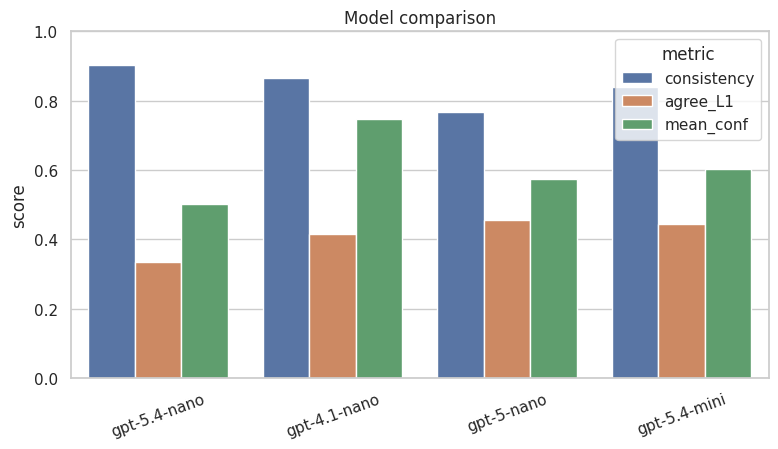

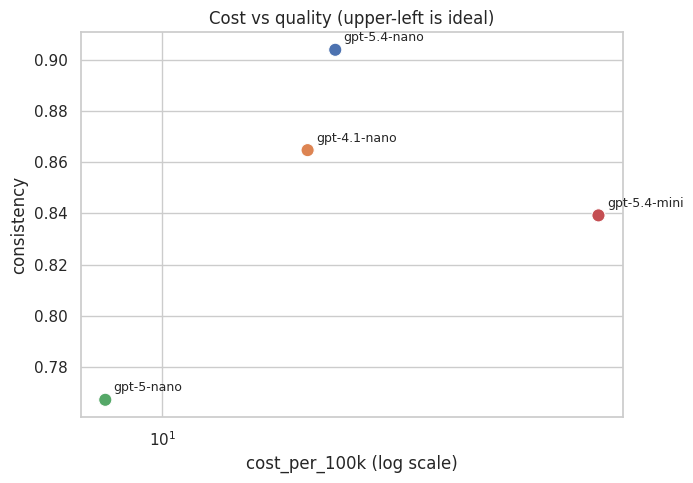

In [15]:
mc = plot_model_comparison(comp)
cvq = plot_cost_vs_quality(comp, quality_col='consistency', cost_col='cost_per_100k')

`gpt-5.4-nano` and `gpt-4.1-nano` dominate here

### Prompt-stability

How many modal codes change between v0 and v4. A model whose answers are highly sensitive to
a small prompt change is not reading the text robustly, whatever its other scores.

,model,codes_flipped,n,flip_rate
0,gpt-5.4-nano,49,102,0.480
1,gpt-4.1-nano,66,100,0.660
2,gpt-5-nano,76,102,0.745


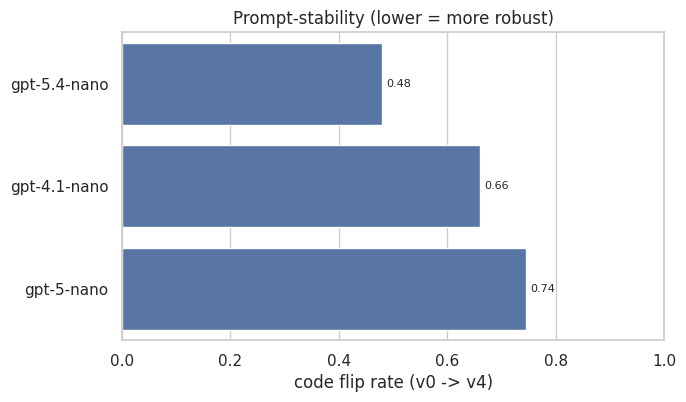

In [19]:
stab = []
for m in ['gpt-5.4-nano', 'gpt-4.1-nano', 'gpt-5-nano']:
    a = cells_of(pd.read_csv(f'{EXP_2}/version_0.csv', dtype={'id': str, 'clc_code': str})
                 if m == 'gpt-5.4-nano' else load(m, 0))
    b = cells_of(load(m, 4))
    stab.append({'model': m, **flip_rate(a, b)})
stab = pd.DataFrame(stab)
display(stab)
fr = plot_flip_rate(stab)

`gpt-5.4-nano` is best.

### Terra: ceiling check

Read per `subset_reason`. The subset was chosen to be hard for the cheap model, so the aggregate is not an accuracy figure for Terra.

The `crux` block is the informative one. If Terra mostly returns the same code as the cheap model while both disagree with CLC, that points at the reference. If Terra mostly agrees with CLC where the cheap model did not, that points at the model.

In [21]:
terra = pd.read_csv(f'{EXP_3}/exp3_gpt-5.6-terra_v4.csv',
                    dtype={'id': str, 'clc_code': str})
tc = cells_of(terra, REF).merge(
    terra_rows[['row_id', 'subset_reason']], left_on='id', right_on='row_id', how='left')
nano4 = cells_of(v4_nano, REF).set_index('id')
tc['nano_code'] = tc['id'].map(nano4['modal_code'])

display(tc.groupby('subset_reason').agg(
    n=('id', 'size'), terra_agree=('agree_L1', 'mean'),
    terra_conf=('mean_conf', 'mean')).round(3))

print('\ncrux rows:')
crux = tc[tc.subset_reason == 'crux_unamb_disagree']
same_as_nano = 0
for _, r in crux.iterrows():
    same = r['modal_code'] == r['nano_code']
    same_as_nano += same
    note = ('terra agrees with CLC' if r['agree_L1'] else
            ('both disagree, same code' if same else 'both disagree, different codes'))
    print(f"  {r['id']}: nano={r['nano_code']} terra={r['modal_code']} ref={r['ref']} — {note}")

print(f"\nTerra agreed with CLC on {int(crux['agree_L1'].sum())}/{len(crux)} crux rows")
print(f"Terra returned the cheap model's code on {same_as_nano}/{len(crux)} crux rows")

,n,terra_agree,terra_conf
subset_reason,,,
boundary_inconsistent,8,0.25,0.843
control_unamb_agree,4,1.0,0.751
crux_unamb_disagree,12,0.25,0.767
cultivated,3,NaN,0.692
thin_hallucination_check,3,0.666667,0.950



crux rows:
  W067: nano=512 terra=512 ref=112 — both disagree, same code
  W069: nano=421 terra=421 ref=112 — both disagree, same code
  W070: nano=231 terra=231 ref=321 — both disagree, same code
  W071: nano=331 terra=331 ref=521 — both disagree, same code
  W072: nano=312 terra=243 ref=231 — terra agrees with CLC
  W078: nano=511 terra=511 ref=312 — both disagree, same code
  W082: nano=131 terra=131 ref=312 — both disagree, same code
  W085: nano=132 terra=132 ref=313 — both disagree, same code
  W089: nano=231 terra=231 ref=312 — both disagree, same code
  W091: nano=512 terra=311 ref=312 — terra agrees with CLC
  W092: nano=511 terra=311 ref=311 — terra agrees with CLC
  W095: nano=231 terra=231 ref=312 — both disagree, same code

Terra agreed with CLC on 3/12 crux rows
Terra returned the cheap model's code on 9/12 crux rows


In [22]:
rows = []
for m in MODELS:
    raw = load(m)
    cl = cells_of(raw, REF)
    rows.append({
        'model': m,
        'consistency': cl['consistency'].mean(),
        'mean_conf': cl['mean_conf'].mean(),
        'agree_L1': cl['agree_L1'].mean(),
        'agree_L3': cl['agree_L3'].mean(),
        'unknown_code': cl['unknown_code'].mean(),
        'rows_lost': int(cl['modal_code'].isna().sum()),
        'cost_per_100k': cost_of(raw['clc_prompt_tokens'].sum(),
                                 raw['clc_completion_tokens'].sum(),
                                 raw['clc_cached_tokens'].sum(), m) / len(raw) * 100_000,
    })
comp = pd.DataFrame(rows)
display(comp.round(4))

,model,consistency,mean_conf,agree_L1,agree_L3,unknown_code,rows_lost,cost_per_100k
0,gpt-5.4-nano,0.9039,0.5027,0.3333,0.0505,0.000,0,22.4854
1,gpt-4.1-nano,0.8647,0.7464,0.4141,0.0505,0.000,0,19.7524
2,gpt-5-nano,0.7672,0.5746,0.4545,0.0808,0.002,0,7.6528
3,gpt-5.4-mini,0.8392,0.6040,0.4444,0.1414,0.000,0,77.2035


## Conclusion

| criterion | outcome |
|---|---|
| validity | `gpt-5-nano` eliminated, rest is valid |
| calibration | `gpt-5.4-mini` had the best calibration |
| consistency | gap between `gpt-5.4-nano`, `gpt-5.4-mini` and `gpt-4.1-nano` was small with `5.4-nano` being the most consistent |
| prompt-stability | `gpt-5.4-nano` was the most stable (`5.4-mini` not tested due to cost) |
| cost per 100k | `gpt-5-nano` best, but eliminated. Next best is `gpt-4.1-nano` |
| Terra ceiling | crux: agreed with CLC 3/12, matched the cheap model 9/12 |

**Model carried forward:** `gpt-5.4-mini` for now, might change based on changing requirements